
# Paso 00c — Masas por nodo, con áreas reales (grunnkretser), no un círculo

**Reemplaza el método de la Tarea 1 original** (`00_recorte_y_masas.ipynb`,
círculo de 1000 m). El círculo trataba a los 4 nodos igual, pero no lo son:
para Bryggen (denso, urbano) capturaba ~30 grunnkretser pequeñas; para
Kleppestø o Laksevåg, apenas 3-4 grandes — los números no eran comparables.

El usuario dibujó a mano 4 áreas de estudio en QGIS (`data/Areas_estudio.gpkg`,
una por estación, sin traslapes). Este notebook:

1. Carga esas 4 áreas y confirma a qué nodo pertenece cada una (por cercanía —
   sin ambigüedad: la distancia al nodo correcto es varias veces menor que a
   cualquier otro).
2. Selecciona qué grunnkretser TOCAN cada área (si el área agarra aunque sea
   un pedacito de una grunnkrets, esa grunnkrets se toma COMPLETA — no se
   parte una unidad real a la mitad; decisión explícita del usuario).
3. Arma la tabla de grunnkretser por nodo (el entregable pedido).
4. Recalcula población y empleo con la unión de esas grunnkretser como zona
   de captación (en vez del círculo) — usando la misma grilla SSB de 250 m de
   siempre, solo cambia la forma de la zona.
5. Genera los mapas de cómo quedan las zonas.
6. Compara los números nuevos contra los del círculo — van a ser distintos.

**A partir de aquí, esta es la tabla de masas canónica** — sobrescribe
`output/masas_por_nodo.csv` (el círculo queda guardado aparte, en
`output/masas_por_nodo_circulo_1km_DEPRECATED.csv`, como referencia histórica).


In [1]:

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import contextily as cx
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import masas
import grunnkretser as gk_mod
import plotting

BASE_DIR = Path.cwd().parent
CONFIG_PATH = BASE_DIR / "config" / "instance.yaml"
OUTPUT_DIR = BASE_DIR / "output"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

cfg = masas.cargar_config(CONFIG_PATH)
nodos_utm = masas.cargar_nodos(cfg, BASE_DIR)

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

COLOR_NODO = {"kleppesto": "#1f6f8b", "laksevag": "#2f7d32", "bryggen": "#c0392b", "sandviken": "#8e44ad"}


## 1. Áreas dibujadas -> nodo

Se asigna cada área al nodo cuyo centro está más cerca del centroide del área.
Se muestran TODAS las distancias, no solo la mínima, para que quede explícito
que no hay ambigüedad (la segunda más cercana está a kilómetros, no a metros).


In [2]:

areas = gk_mod.cargar_areas_estudio(BASE_DIR / "data" / "Areas_estudio.gpkg", nodos_utm)
areas[["distancia_nodo_m", "area_km2"]]


,distancia_nodo_m,area_km2
nodo,,
kleppesto,3936.152260,57.760145
bryggen,355.519771,4.943741
laksevag,1471.454105,5.958548
sandviken,535.959964,5.246778


In [3]:

# Verificación explícita de que la asignación no es ambigua: para cada área,
# la distancia al nodo asignado vs. la distancia al segundo más cercano.
for nid, row in areas.iterrows():
    c = row.geometry.centroid
    dists = sorted((nodos_utm.loc[n, "geometry"].distance(c), n) for n in nodos_utm.index)
    print(f"área -> {nid}: más cercano {dists[0][1]} ({dists[0][0]:.0f} m), "
          f"2do más cercano {dists[1][1]} ({dists[1][0]:.0f} m) -> {dists[1][0]/dists[0][0]:.1f}x más lejos")


área -> kleppesto: más cercano kleppesto (3936 m), 2do más cercano laksevag (6388 m) -> 1.6x más lejos
área -> bryggen: más cercano bryggen (356 m), 2do más cercano sandviken (3484 m) -> 9.8x más lejos
área -> laksevag: más cercano laksevag (1471 m), 2do más cercano bryggen (2314 m) -> 1.6x más lejos
área -> sandviken: más cercano sandviken (536 m), 2do más cercano bryggen (3625 m) -> 6.8x más lejos


## 2. Grunnkretser dentro de cada área

Criterio: el CENTROIDE de la grunnkrets cae dentro del área dibujada (mismo
criterio "centro adentro" usado en toda la Tarea 1 original, para que el
método sea consistente).


In [4]:

gk_norge = gk_mod.descargar_grunnkretser(PROCESSED_DIR / "grunnkretser_norge.parquet")
gk_bergen_askoy = gk_mod.grunnkretser_bergen_askoy(gk_norge)

grunnkretser_por_nodo = {}
for nid, row in areas.iterrows():
    seleccion = gk_mod.seleccionar_grunnkretser_por_area(gk_bergen_askoy, row.geometry)
    grunnkretser_por_nodo[nid] = seleccion
    print(f"{nid}: {len(seleccion)} grunnkretser (antes de resolver duplicados)")

# Con el criterio de interseccion, una grunnkrets en el borde entre dos areas
# puede quedar seleccionada en ambas -- se resuelve dejandola solo donde tiene
# mas superposicion.
grunnkretser_por_nodo = gk_mod.resolver_duplicados(grunnkretser_por_nodo, areas)
print()
for nid, seleccion in grunnkretser_por_nodo.items():
    print(f"{nid}: {len(seleccion)} grunnkretser (final, sin duplicados)")


kleppesto: 28 grunnkretser (antes de resolver duplicados)
bryggen: 68 grunnkretser (antes de resolver duplicados)
laksevag: 18 grunnkretser (antes de resolver duplicados)
sandviken: 21 grunnkretser (antes de resolver duplicados)

kleppesto: 28 grunnkretser (final, sin duplicados)
bryggen: 67 grunnkretser (final, sin duplicados)
laksevag: 18 grunnkretser (final, sin duplicados)
sandviken: 21 grunnkretser (final, sin duplicados)


### Verificación de duplicados (grunnkretser en el borde entre dos áreas)

Con el criterio "toca" (en vez de "centro adentro"), una grunnkrets justo en el
borde entre dos áreas puede tocar a ambas. Se verifica explícitamente cuáles
fueron los casos y a quién se le asignó cada una (por mayor superposición).


In [5]:
import pandas as pd

todas_antes = pd.concat([
    gk_mod.seleccionar_grunnkretser_por_area(gk_bergen_askoy, areas.loc[nid, "geometry"]).assign(nodo=nid)
    for nid in areas.index
], ignore_index=True)
conteo = todas_antes["grunnkretsnummer"].value_counts()
duplicadas = conteo[conteo > 1]
print(f"Grunnkretser que tocan más de un área: {len(duplicadas)}")
if len(duplicadas):
    for gknum in duplicadas.index:
        nodos_involucrados = todas_antes.loc[todas_antes["grunnkretsnummer"] == gknum, ["nodo", "grunnkretsnavn"]]
        asignada_a = [nid for nid, df in grunnkretser_por_nodo.items() if gknum in df["grunnkretsnummer"].values]
        print(f"  {gknum} ({nodos_involucrados['grunnkretsnavn'].iloc[0]}): tocaba {nodos_involucrados['nodo'].tolist()} -> asignada a {asignada_a}")


Grunnkretser que tocan más de un área: 1
  46010637 (Sandviksfjellet): tocaba ['bryggen', 'sandviken'] -> asignada a ['sandviken']


## 3. Tabla de grunnkretser por nodo (entregable)


In [6]:

filas_tabla = []
for nid, gdf in grunnkretser_por_nodo.items():
    for _, r in gdf.iterrows():
        filas_tabla.append({
            "nodo": nid,
            "nombre_nodo": nodos_utm.loc[nid, "nombre"],
            "grunnkretsnummer": r["grunnkretsnummer"],
            "grunnkretsnavn": r["grunnkretsnavn"],
            "kommunenummer": r["kommunenummer"],
        })
tabla_grunnkretser_por_nodo = pd.DataFrame(filas_tabla)
tabla_grunnkretser_por_nodo.to_csv(OUTPUT_DIR / "grunnkretser_seleccionadas_por_nodo.csv", index=False)
print(f"{len(tabla_grunnkretser_por_nodo)} filas guardadas en output/grunnkretser_seleccionadas_por_nodo.csv")
tabla_grunnkretser_por_nodo


134 filas guardadas en output/grunnkretser_seleccionadas_por_nodo.csv


,nodo,nombre_nodo,grunnkretsnummer,grunnkretsnavn,kommunenummer
0,kleppesto,Kleppestø (Askøy),46270705,Kollevåg,4627
1,kleppesto,Kleppestø (Askøy),46270104,Hop,4627
2,kleppesto,Kleppestø (Askøy),46270702,Ravnanger,4627
3,kleppesto,Kleppestø (Askøy),46270703,Tveit-Tveitevåg,4627
4,kleppesto,Kleppestø (Askøy),46270302,Florvåg,4627
...,...,...,...,...,...
129,sandviken,Sandviken (BSI Padling),46010704,Tømmervågen,4601
130,sandviken,Sandviken (BSI Padling),46010617,Måseskjæret,4601
131,sandviken,Sandviken (BSI Padling),46010609,Stemmemyren,4601
132,sandviken,Sandviken (BSI Padling),46010614,Nyhavn,4601


## 4. Recalcular masas con las zonas nuevas

Unión de las grunnkretser de cada nodo como zona de captación, sobre la misma
grilla SSB de 250 m (Tareas 0-1 originales) — cambia la forma de la zona, no
la fuente de los números.


In [7]:

pop_recortada = gpd.read_parquet(PROCESSED_DIR / "poblacion_bergen_askoy.parquet")
bedrifter_recortada = gpd.read_parquet(PROCESSED_DIR / "bedrifter_bergen_askoy.parquet")

zonas_por_nodo = {nid: gdf.union_all() for nid, gdf in grunnkretser_por_nodo.items()}

resumen_v2, celdas_pop_por_nodo_v2, celdas_emp_por_nodo_v2 = masas.calcular_masas_por_zona(
    cfg, nodos_utm, zonas_por_nodo, pop_recortada, bedrifter_recortada,
)
resumen_v2


,nombre,area_zona_km2,n_celdas_poblacion,poblacion_total,poblacion_min_celda,poblacion_max_celda,poblacion_media_celda,poblacion_mediana_celda,n_celdas_bedrifter,establecimientos_total,empleo_total,empleo_min_celda,empleo_max_celda,empleo_media_celda,empleo_mediana_celda
id,,,,,,,,,,,,,,,
kleppesto,Kleppestø (Askøy),80.59,468,25153,1,317,53.75,33.5,369,1884,7550,0,444,20.46,1.0
laksevag,Laksevåg (Gravdal),14.85,84,15986,1,804,190.31,142.5,83,1447,7760,0,1480,93.49,27.0
bryggen,Bryggen / Sentrum,20.21,75,27695,1,1348,369.27,288.0,85,7101,52213,0,4151,614.27,248.0
sandviken,Sandviken (BSI Padling),14.61,72,11109,1,635,154.29,135.5,65,879,4106,0,955,63.17,7.0


In [8]:

resumen_v2.to_csv(OUTPUT_DIR / "masas_por_nodo.csv")
print("Guardado (sobrescribe la tabla canónica):", OUTPUT_DIR / "masas_por_nodo.csv")


Guardado (sobrescribe la tabla canónica): c:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\demand\output\masas_por_nodo.csv


## 5. Comparación: círculo (1 km) vs. grunnkretser elegidas a mano


In [9]:

resumen_v1 = pd.read_csv(OUTPUT_DIR / "masas_por_nodo_circulo_1km_DEPRECATED.csv", index_col="id")

comparacion = pd.DataFrame({
    "area_km2_circulo": np.pi * (cfg["captacion"]["radio_m"] / 1000) ** 2,
    "area_km2_grunnkretser": resumen_v2["area_zona_km2"],
    "poblacion_circulo": resumen_v1["poblacion_total"],
    "poblacion_grunnkretser": resumen_v2["poblacion_total"],
    "empleo_circulo": resumen_v1["empleo_total"],
    "empleo_grunnkretser": resumen_v2["empleo_total"],
})
comparacion["poblacion_dif_%"] = ((comparacion["poblacion_grunnkretser"] / comparacion["poblacion_circulo"] - 1) * 100).round(1)
comparacion["empleo_dif_%"] = ((comparacion["empleo_grunnkretser"] / comparacion["empleo_circulo"] - 1) * 100).round(1)
comparacion


,area_km2_circulo,area_km2_grunnkretser,poblacion_circulo,poblacion_grunnkretser,empleo_circulo,empleo_grunnkretser,poblacion_dif_%,empleo_dif_%
id,,,,,,,,
kleppesto,3.141593,80.59,2177,25153,1922,7550,1055.4,292.8
laksevag,3.141593,14.85,2321,15986,1655,7760,588.8,368.9
bryggen,3.141593,20.21,18602,27695,35333,52213,48.9,47.8
sandviken,3.141593,14.61,5291,11109,2858,4106,110.0,43.7


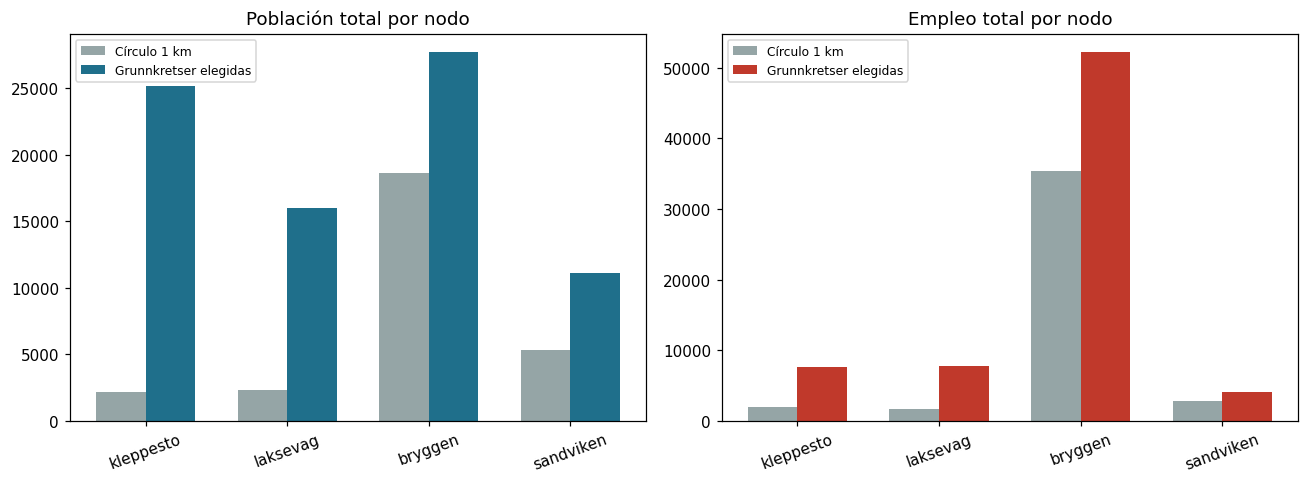

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(comparacion))
w = 0.35

axes[0].bar(x - w/2, comparacion["poblacion_circulo"], width=w, label="Círculo 1 km", color="#95a5a6")
axes[0].bar(x + w/2, comparacion["poblacion_grunnkretser"], width=w, label="Grunnkretser elegidas", color="#1f6f8b")
axes[0].set_xticks(x); axes[0].set_xticklabels(comparacion.index, rotation=20)
axes[0].set_title("Población total por nodo"); axes[0].legend(fontsize=8)

axes[1].bar(x - w/2, comparacion["empleo_circulo"], width=w, label="Círculo 1 km", color="#95a5a6")
axes[1].bar(x + w/2, comparacion["empleo_grunnkretser"], width=w, label="Grunnkretser elegidas", color="#c0392b")
axes[1].set_xticks(x); axes[1].set_xticklabels(comparacion.index, rotation=20)
axes[1].set_title("Empleo total por nodo"); axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "comparacion_circulo_vs_grunnkretser.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Mapas: cómo quedan las áreas de cada nodo


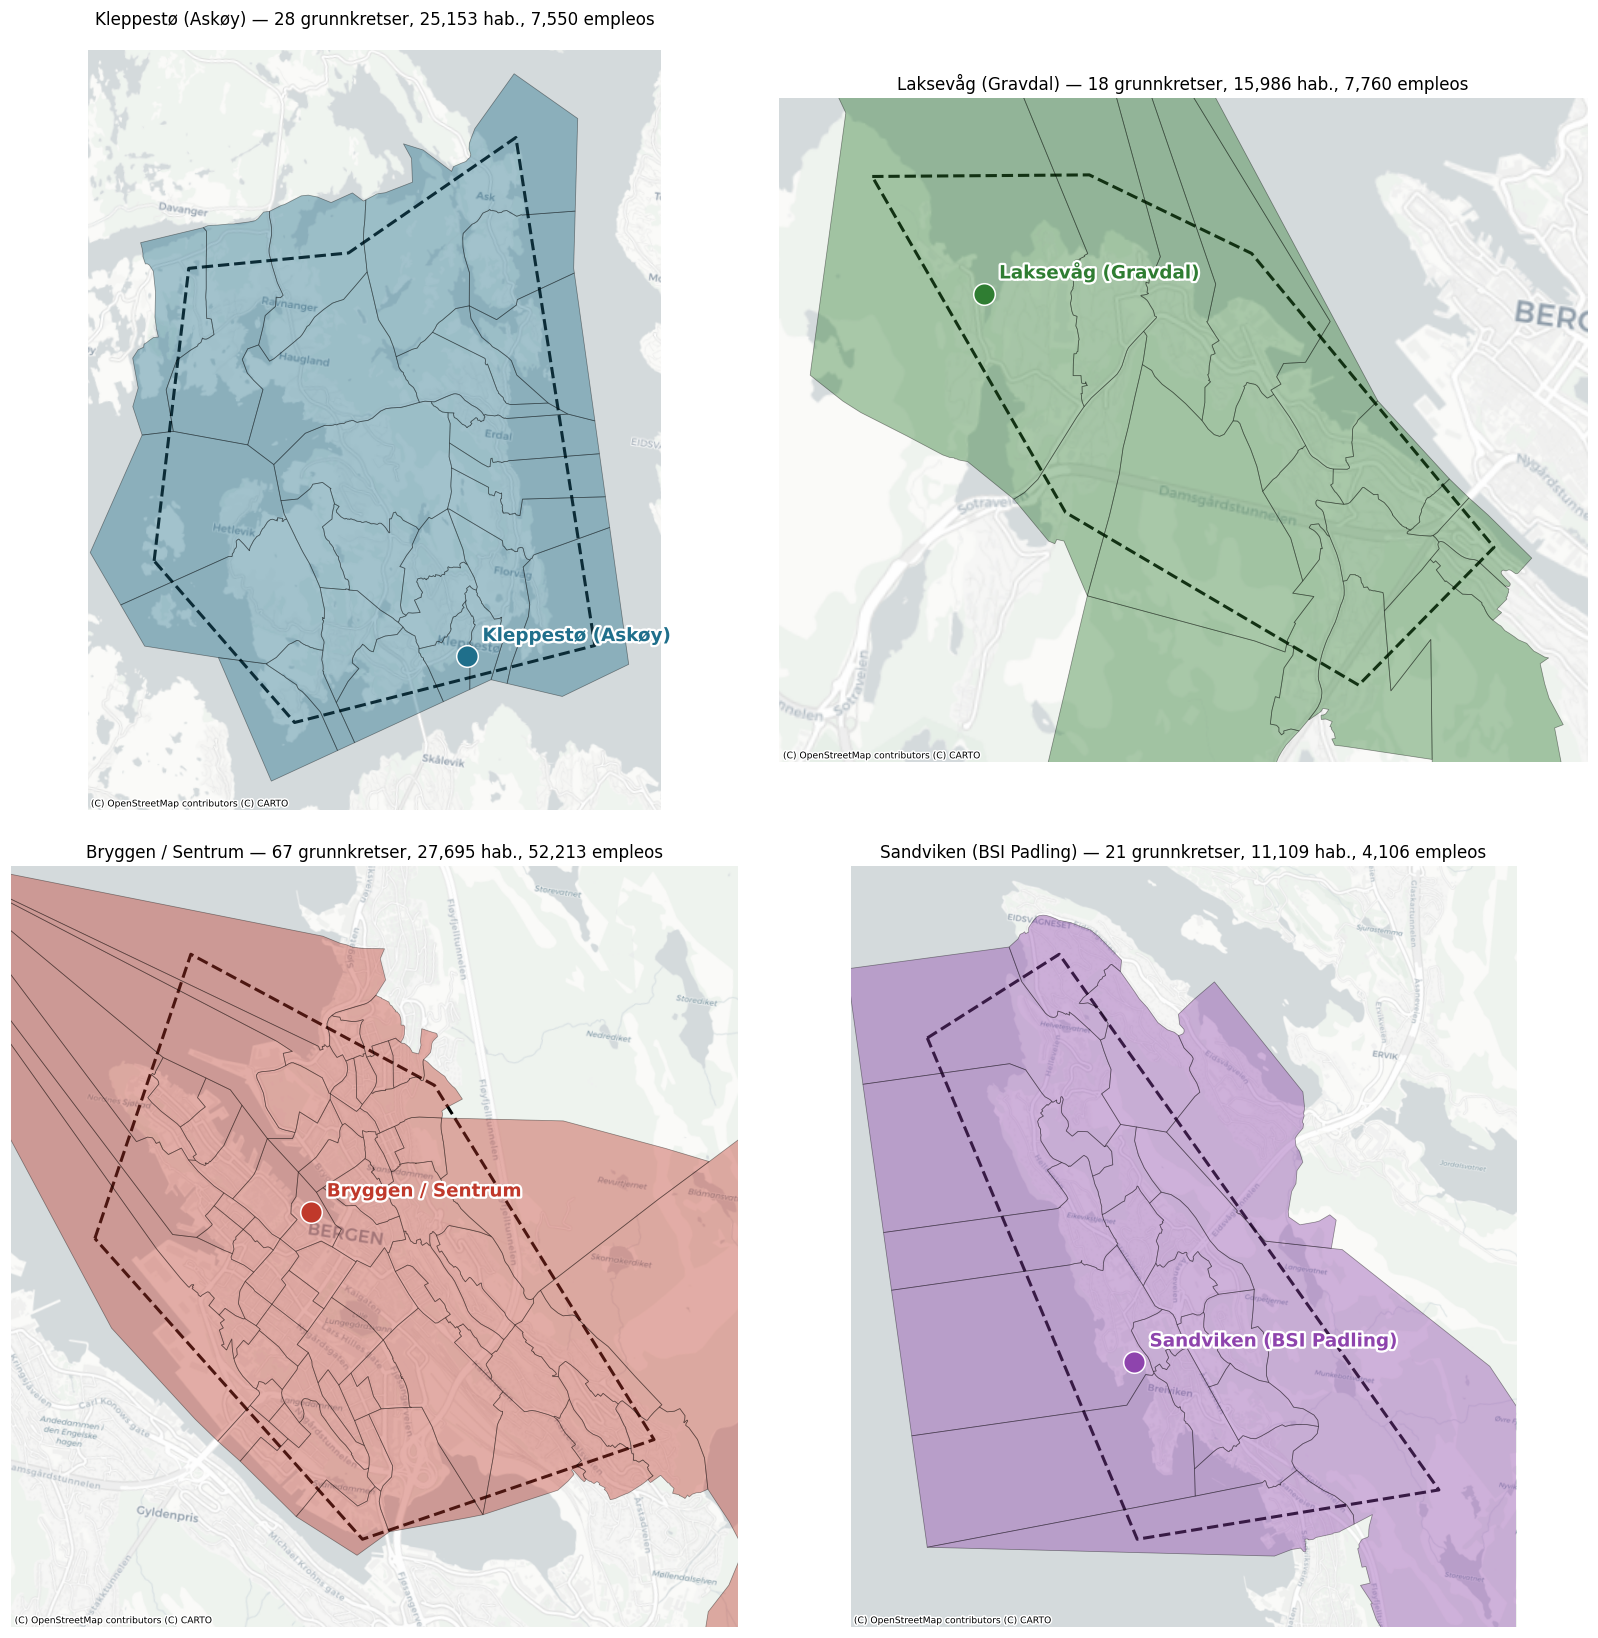

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(15, 15))

for ax, (nid, row) in zip(axes.flat, nodos_utm.iterrows()):
    area_geom = areas.loc[nid, "geometry"]
    seleccion = grunnkretser_por_nodo[nid]

    gpd.GeoSeries([area_geom], crs="EPSG:32633").boundary.plot(ax=ax, color="black", linewidth=2, linestyle="--", zorder=2)
    seleccion.plot(ax=ax, facecolor=COLOR_NODO[nid], edgecolor="black", linewidth=0.5, alpha=0.4, zorder=3)

    ax.scatter([row.geometry.x], [row.geometry.y], color=COLOR_NODO[nid], edgecolor="white", s=200, zorder=5)
    ax.annotate(
        row["nombre"], xy=(row.geometry.x, row.geometry.y), xytext=(10, 10), textcoords="offset points",
        fontsize=12, fontweight="bold", color=COLOR_NODO[nid], zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

    xmin, ymin, xmax, ymax = area_geom.bounds
    mx, my = (xmax - xmin) * 0.15, (ymax - ymin) * 0.15
    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs="EPSG:32633", attribution_size=6)
    ax.set_axis_off()
    ax.set_title(f"{row['nombre']} — {len(seleccion)} grunnkretser, {resumen_v2.loc[nid,'poblacion_total']:,} hab., {resumen_v2.loc[nid,'empleo_total']:,} empleos", fontsize=11)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapas_zonas_grunnkretser_por_nodo.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Vista general (las 4 zonas juntas)


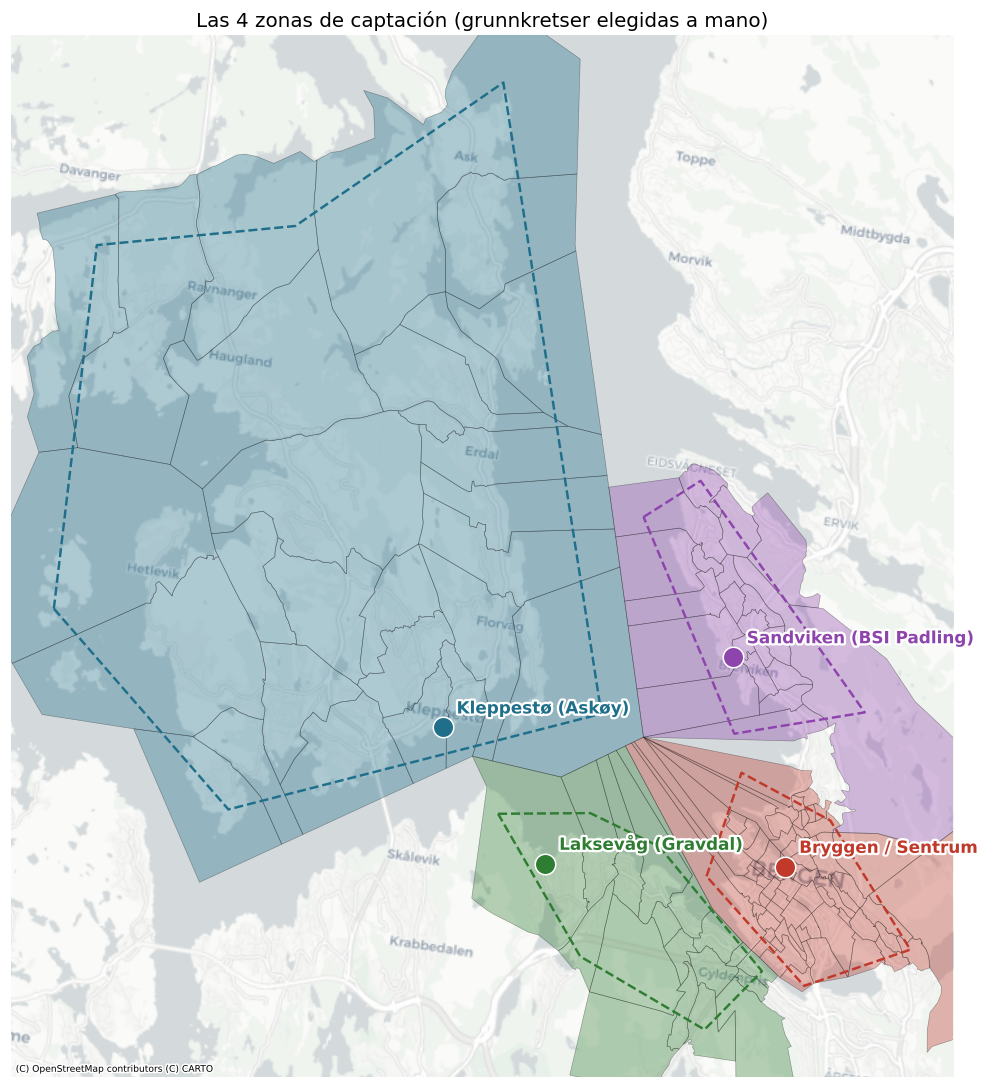

In [12]:

fig, ax = plt.subplots(figsize=(11, 10))

for nid, row in nodos_utm.iterrows():
    seleccion = grunnkretser_por_nodo[nid]
    seleccion.plot(ax=ax, facecolor=COLOR_NODO[nid], edgecolor="black", linewidth=0.4, alpha=0.35, zorder=2)
    gpd.GeoSeries([areas.loc[nid, "geometry"]], crs="EPSG:32633").boundary.plot(ax=ax, color=COLOR_NODO[nid], linewidth=1.6, linestyle="--", zorder=3)
    ax.scatter([row.geometry.x], [row.geometry.y], color=COLOR_NODO[nid], edgecolor="white", s=180, zorder=5)
    ax.annotate(
        row["nombre"], xy=(row.geometry.x, row.geometry.y), xytext=(9, 9), textcoords="offset points",
        fontsize=11, fontweight="bold", color=COLOR_NODO[nid], zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

xmin, ymin, xmax, ymax = areas.total_bounds
mx, my = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
ax.set_xlim(xmin - mx, xmax + mx)
ax.set_ylim(ymin - my, ymax + my)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs="EPSG:32633", attribution_size=6)
ax.set_axis_off()
ax.set_title("Las 4 zonas de captación (grunnkretser elegidas a mano)", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_general_zonas_grunnkretser.png", dpi=180, bbox_inches="tight")
plt.show()



## Resumen

- **Reemplaza la Tarea 1 original** (círculo de 1 km): las zonas de captación
  ahora son la unión de grunnkretser elegidas a mano dentro de las 4 áreas
  dibujadas por el usuario (`data/Areas_estudio.gpkg`).
- `output/grunnkretser_seleccionadas_por_nodo.csv`: tabla de qué grunnkretser
  (número + nombre) quedaron en cada nodo.
- `output/masas_por_nodo.csv`: **sobrescrita** con los nuevos totales — esta
  es la tabla canónica de aquí en adelante. El círculo queda en
  `output/masas_por_nodo_circulo_1km_DEPRECATED.csv` como referencia histórica.
- `output/comparacion_circulo_vs_grunnkretser.png`: los números cambiaron,
  como se esperaba.
- `output/mapas_zonas_grunnkretser_por_nodo.png` y `mapa_general_zonas_grunnkretser.png`:
  verificación visual de las 4 zonas.
- **Pendiente:** las Tareas 3 (patrón O-D) y 4 (llegadas) leen
  `output/masas_por_nodo.csv` por nombre de archivo — con solo volver a
  correr `02_patron_od.ipynb` y `03_llegadas.ipynb`, recogen los números
  nuevos automáticamente, sin cambiar código.
